# Vorgeplänkel
## Work Environment aufsetzen

In [2]:
"""
# Hier die kompletten Schritte zum Copy-Pasten ins Terminal:

# 1. Neue Umgebung erstellen (nur einmal nötig)
conda create -n nlp-llm python=3.11 -y

# 2. Umgebung aktivieren (das machst du jedes Mal, wenn du daran arbeitest)
conda activate nlp-llm

# 3. PyTorch installieren
pip install torch torchvision torchaudio

# 4. Übliche NLP/LLM-Pakete dazu
pip install transformers datasets tokenizers jupyter ipykernel scikit-learn pandas numpy matplotlib

# 5. Damit Jupyter/VS Code diese Umgebung als Kernel erkennt
python -m ipykernel install --user --name nlp-llm --display-name "Python (nlp-llm)"
"""

'\n# Hier die kompletten Schritte zum Copy-Pasten ins Terminal:\n\n# 1. Neue Umgebung erstellen (nur einmal nötig)\nconda create -n nlp-llm python=3.11 -y\n\n# 2. Umgebung aktivieren (das machst du jedes Mal, wenn du daran arbeitest)\nconda activate nlp-llm\n\n# 3. PyTorch installieren\npip install torch torchvision torchaudio\n\n# 4. Übliche NLP/LLM-Pakete dazu\npip install transformers datasets tokenizers jupyter ipykernel scikit-learn pandas numpy matplotlib\n\n# 5. Damit Jupyter/VS Code diese Umgebung als Kernel erkennt\npython -m ipykernel install --user --name nlp-llm --display-name "Python (nlp-llm)"\n'

## Überblick Review-Datensatz

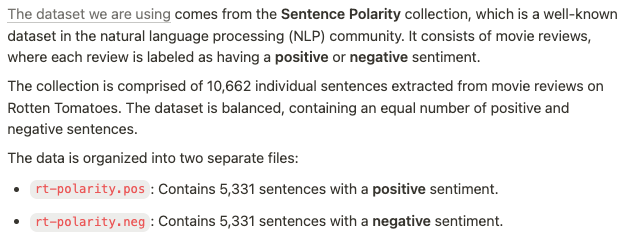

## Ziele der Übung

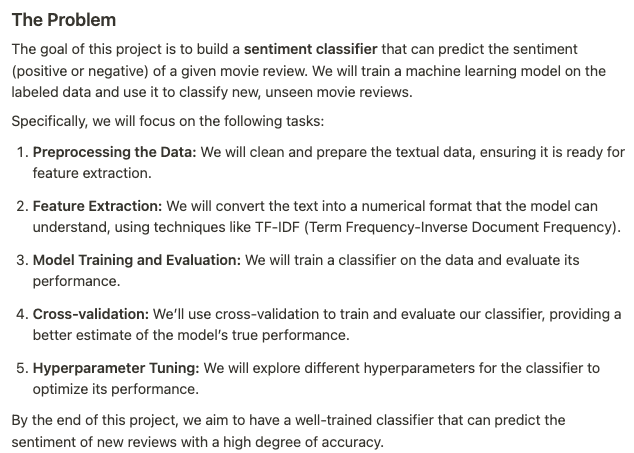

# Importing Libraries

In [3]:
# Importing necessary libraries
import numpy as np  # for numerical operations
import pandas as pd  # for data manipulation
import random  # for shuffling the data
import nltk
import re  # for handling regular expressions

from nltk.stem import WordNetLemmatizer  # for lemmatizing words
from nltk.corpus import stopwords  # for stop word removal
from nltk.tokenize import word_tokenize  # for tokenizing sentences into words
nltk.download('punkt_tab')  # Downloads the 'punkt' tokenizer table used for tokenization of text into sentences or words

# Downloading necessary NLTK resources
## nltk.download(...) lädt zur Laufzeit Daten/Modelle nach, die NLTK selbst nicht mitbringt – das Package enthält nur den Code (Tokenizer-Logik, Lemmatizer-Klasse etc.), nicht die Sprachdaten.
nltk.download('stopwords')  # List of common stop words in English
nltk.download('punkt')  # Pre-trained tokenizer models
nltk.download('wordnet')  # WordNet lemmatizer dataset

# Libraries for text feature extraction and model training
from sklearn.feature_extraction.text import TfidfVectorizer  # Convert text into numerical features (TF-IDF)
from sklearn.linear_model import LogisticRegression  # Logistic regression for classification
from sklearn.svm import LinearSVC  # Support Vector Machines for classification

# Libraries for model evaluation
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix  # For model evaluation metrics
from sklearn.model_selection import KFold, cross_val_score  # For cross-validation

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/matthiasmuschket/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/matthiasmuschket/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/matthiasmuschket/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/matthiasmuschket/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# Load & Prepare Dataset
## Load

In [4]:
import nltk
nltk.download('sentence_polarity')
from nltk.corpus import sentence_polarity

df_sent_pos = pd.DataFrame([' '.join(s) for s in sentence_polarity.sents(categories='pos')])
df_sent_neg = pd.DataFrame([' '.join(s) for s in sentence_polarity.sents(categories='neg')])

print(df_sent_pos.head())

                                                   0
0  the rock is destined to be the 21st century's ...
1  the gorgeously elaborate continuation of " the...
2                     effective but too-tepid biopic
3  if you sometimes like to go to the movies to h...
4  emerges as something rare , an issue movie tha...


[nltk_data] Downloading package sentence_polarity to
[nltk_data]     /Users/matthiasmuschket/nltk_data...
[nltk_data]   Package sentence_polarity is already up-to-date!


## Rename Columns

In [5]:
# Rename column 0 to 'sentence'
# inplace=True ensures the changes are applied directly to the dataframes.
df_sent_pos.rename(columns={0: "sentence"}, inplace=True)
df_sent_neg.rename(columns={0: "sentence"}, inplace=True)

# Data Preprocessing
## Define Function

In [6]:
# Define the preprocessing function
def preprocess_text(sentences):
    # Convert all tokens to lowercase
    sentences = [sentence.lower() for sentence in sentences]

    # Remove punctuation using regex
    sentences = [re.sub(r"[^\w\s]", "", sentence) for sentence in sentences]

    # Remove extra whitespace between words
    sentences = [" ".join(sentence.split()) for sentence in sentences]

    # Tokenize sentences into words
    sentences = [word_tokenize(sentence) for sentence in sentences]

    # Remove stop words
    stop_words = set(stopwords.words('english'))  # Load English stop words
    filtered_sentences = []
    for sentence in sentences:
        filtered_sentence = [word for word in sentence if word not in stop_words]
        filtered_sentences.append(filtered_sentence)

    # Lemmatize words
    lemmatizer = WordNetLemmatizer()
    lemmatized_sentences = []
    for sentence in filtered_sentences:
        lemmatized_sentence = [lemmatizer.lemmatize(word) for word in sentence]
        lemmatized_sentences.append(lemmatized_sentence)
    return [' '.join(sentence) for sentence in lemmatized_sentences]

## Apply Function

In [7]:
# Preprocess the sentences
pos_preprocessed_sentences = preprocess_text(df_sent_pos['sentence'])
neg_preprocessed_sentences = preprocess_text(df_sent_neg['sentence'])

# Print the first preprocessed negative sentence
print(neg_preprocessed_sentences[0])

simplistic silly tedious


In [8]:
print(df_sent_pos.head())
print()
print(pos_preprocessed_sentences)


                                            sentence
0  the rock is destined to be the 21st century's ...
1  the gorgeously elaborate continuation of " the...
2                     effective but too-tepid biopic
3  if you sometimes like to go to the movies to h...
4  emerges as something rare , an issue movie tha...

['rock destined 21st century new conan he going make splash even greater arnold schwarzenegger jeanclaud van damme steven segal', 'gorgeously elaborate continuation lord ring trilogy huge column word adequately describe cowriterdirector peter jackson expanded vision j r r tolkien middleearth', 'effective tootepid biopic', 'sometimes like go movie fun wasabi good place start', 'emerges something rare issue movie thats honest keenly observed doesnt feel like one', 'film provides great insight neurotic mindset comic even reached absolute top game', 'offer rare combination entertainment education', 'perhaps picture ever made literally showed road hell paved good intention', 's

## Combine Datasets

In [9]:
# Combine preprocessed positive and negative sentences
sentences = pos_preprocessed_sentences + neg_preprocessed_sentences

## Create Labels

In [10]:
# Create a list for all labels
polarities = []
polarities.extend([0] * len(df_sent_neg))  # Label negative sentences as 0
polarities.extend([1] * len(df_sent_pos))  # Label positive sentences as 1

## Train-Test-Split UMSTÄNDLICH
### Shuffle Data

In [11]:
# Combine sentences and labels into a single list of tupels
combined = list(zip(sentences, polarities))

# Shuffle the combined list
random.shuffle(combined)

# Split the shuffled list back into sentences and labels
sentences[:], polarities[:] = zip(*combined)

In [12]:
combined

[('establishes ominous mood tension swiftly suspense never rise higher level nevertheless maintained throughout',
  0),
 ('film make strong argument regarding social status america indigenous people really exists try eke emotional tug heart one fails get',
  1),
 ('word frankly dear dont give damn never appropriate', 1),
 ('talent actor help moonlight mile rise heartonitssleeve writing', 0),
 ('aside fact film idiotically us website feardotcom com improperly hammy performance poor stephen rea film get added disdain fact nearly impossible look understand',
  1),
 ('live mood rather savour story', 0),
 ('settled world war ii memory found strangely moved even corniest hackneyed contrivance',
  0),
 ('humble opinion praise love lack even fragmented charm found almost previous work',
  1),
 ('throwaway junkfood movie whose rap soundtrack better tended film', 1),
 ('neither funny suspenseful particularly welldrawn', 1),
 ('patchy combination soap opera lowtech magic realism time ploddingly s

### Split Dataset

In [13]:
# Define train-test split ratio
train_test_ratio = 0.8

# Calculate the size of the training set
train_set_size = int(train_test_ratio * len(sentences))

# Split data into training and test sets
X_train, X_test = sentences[:train_set_size], sentences[train_set_size:]
y_train, y_test = polarities[:train_set_size], polarities[train_set_size:]

# Print sizes of training and test sets
print("Size of training set:", len(X_train))
print("Size of test set:", len(X_test))

Size of training set: 8529
Size of test set: 2133


## Train-Test-Split StraightForward

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    sentences, polarities,
    test_size=0.2,
    stratify=polarities,
    random_state=42
)

print("Size of training set:", len(X_train))
print("Size of test set:", len(X_test))

Size of training set: 8529
Size of test set: 2133


## Vectorization: TF-IDF
### Wichtig hierbei!!

**(I) Grundlegend**
- `fit_transform()` wird **NUR** auf Trainingsdaten angewendet
- `transform()` wird dann auf Testdaten angewendet
-


**(II) `fit_transform` kann auch in 2 Schritten gemacht werden**
- Schritt 1: Vokabular lernen (welche Wörter gibt es, IDF-Gewichte berechnen) => `tfidf_vectorizer.fit(X_train)`
- Schritt 2: Trainingsdaten in TF-IDF-Matrix umwandeln => `X_train_tfidf = tfidf_vectorizer.transform(X_train)`
-

**(III) Welche Probleme würden auftreten, wenn `fit_transform` auf Trainings- und Testdaten angewendet werden würde**
- (a) Problem mit Matrix Format:
    - würde der Vectorizer ein neues Vokabular aus den Testdaten lernen, das nicht mehr mit dem Trainingsvokabular übereinstimmt (andere Spaltenanzahl/-bedeutung in der Matrix)
- (b) Data leakage
    - Wenn du fit() auf X_test (oder auf Train+Test kombiniert) aufrufen würdest, würde die IDF-Berechnung auch zählen, in wie vielen Test-Dokumenten ein Wort vorkommt. Das bedeutet: die Gewichtung eines Wortes im Trainingsset würde dann davon beeinflusst, wie häufig dieses Wort im (eigentlich "unsichtbaren") Testset vorkommt
    - Das Testset soll aber "unsichtbare, zukünftige Daten" simulieren. In der Realität, wenn dein Modell live im Einsatz ist, kennst du die neuen Anfragen ja auch nicht vorab, um deine Feature-Statistiken daran anzupassen

### ... of Train data

In [15]:
# Import TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Define the vectorizer with default parameters
tfidf_vectorizer = TfidfVectorizer()

# Transform the training data into a TF-IDF matrix
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Check the number of samples and features
num_samples, num_features = X_train_tfidf.shape
print("#Samples: {}, #Features: {}".format(num_samples, num_features))

#Samples: 8529, #Features: 16460


In [16]:
# Kleinen Ausschnitt als lesbares DataFrame ansehen
import pandas as pd

feature_names = tfidf_vectorizer.get_feature_names_out()

# Nur erste 5 Sätze, alle Features
df_tfidf = pd.DataFrame(
    X_train_tfidf[:5].toarray(),
    columns=feature_names
)
df_tfidf

,00,000,10,100,100minute,100year,101,102minute,105,10course,...,zwick,zzzzzzzzz,às,ápice,élan,ótimo,último,últimos,única,único
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### ... of Test data

In [17]:
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# ML - Logistic Regression
## Model training

In [18]:
# Import the Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Train the Logistic Regression classifier
logistic_regression_classifier = LogisticRegression().fit(X_train_tfidf, y_train)

## Predict sentiment

In [19]:
# Predict polarities for the test data
y_pred = logistic_regression_classifier.predict(X_test_tfidf)

## Evaluation
### ... via Evaluation Report

In [20]:
# Import evaluation metrics
from sklearn.metrics import classification_report, accuracy_score

# Generate and display the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.74      0.74      1067
           1       0.74      0.74      0.74      1066

    accuracy                           0.74      2133
   macro avg       0.74      0.74      0.74      2133
weighted avg       0.74      0.74      0.74      2133



### ... after K-Fold Cross Validation

- Bei K-Fold CV rotierst du innerhalb deines Trainingssets (also X_train aus deinem vorherigen Split) durch k Folds.
- Jede Fold, die gerade nicht zum Trainieren verwendet wird, dient dazu, die Modellgüte
- Dein X_test/y_test (die 20%, die du am Anfang abgespalten hast) bleibt davon komplett unberührt und wird typischerweise erst nach Abschluss der CV-Modellauswahl ein einziges Mal verwendet, um die finale, unverfälschte Generalisierungsleistung zu schätzen

In [21]:
# Import necessary library
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

# Perform 10-fold cross-validation on the training data
f1_scores_list = cross_val_score(
    LogisticRegression(),            # Model: Logistic Regression
    X_train_tfidf,                   # Features: TF-IDF transformed training data
    y_train,                         # Labels: Training labels
    cv=10,                           # Number of folds
    scoring="f1"                     # Evaluation metric: F1 score
)

# Display the F1 scores for each fold
print(f"F1 Scores for each fold: {f1_scores_list}")

# Calculate and display the mean and standard deviation of the F1 scores
print("F1 Score (Mean/Average): {:.3f}".format(f1_scores_list.mean()))
print("F1 Score (Standard Deviation): {:.3f}".format(f1_scores_list.std()))

F1 Scores for each fold: [0.75949367 0.75321637 0.77855478 0.76023392 0.74709977 0.7453271
 0.774942   0.74912485 0.76869159 0.73095238]
F1 Score (Mean/Average): 0.757
F1 Score (Standard Deviation): 0.014


## Hyperparameter Tuning
### Theorie

**(a) Theorie zu Hyperparameter Tuning**
- Hyperparameters are not learned from the data
- Hyperparameters
    - algorithm-specific parameters
    - data transformation parameters (we are going to use the n-gram parameter during TF-IDF vectorization)
    - general parameters like learning rates in neural networks

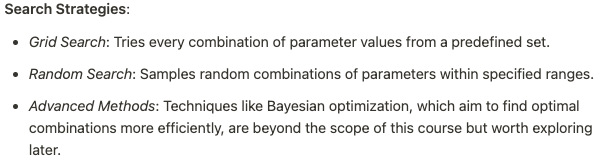

**Theorie N-Gramme**

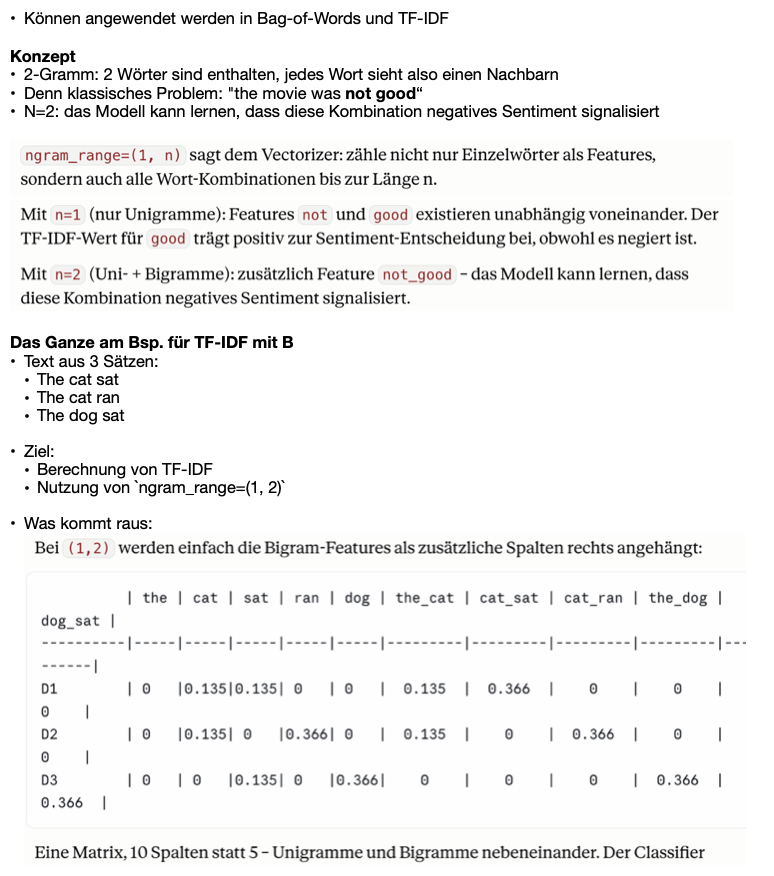

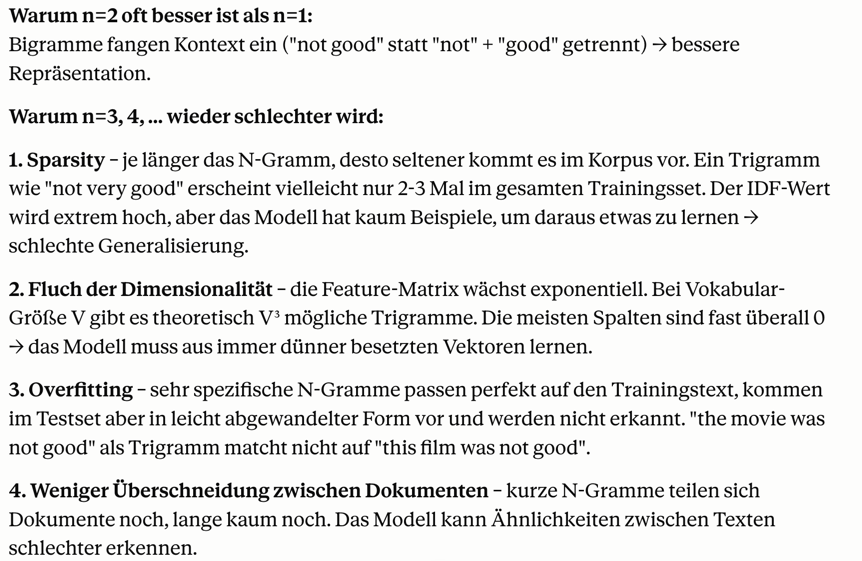
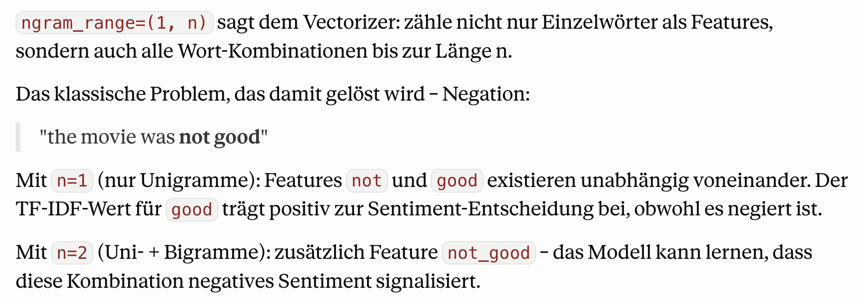
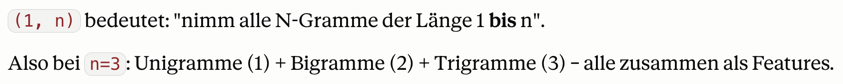

### Setting up the Experiment

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score

# Initialize placeholders to store the best configuration
best_score = -1.0
best_classifier = None
best_ngram_size = -1

# Define the hyperparameters to test
classifiers = [LinearSVC(), LogisticRegression(solver="sag")]
ngram_sizes = [1, 2, 3, 4]

# Loop through all combinations of classifiers and n-gram sizes
for classifier in classifiers:
    for n in ngram_sizes:
        # Define the vectorizer with the current n-gram size
        vectorizer = TfidfVectorizer(ngram_range=(1, n))
        X_train_tfidf = vectorizer.fit_transform(X_train)  # Transform training data

        # Perform 10-fold cross-validation
        f1_scores = cross_val_score(
            classifier,            # Model: LinearSVC(), LogisticRegression
            X_train_tfidf,         # Features: TF-IDF transformed training data
            y_train,               # Labels: Training labels
            cv=10,                 # Number of folds
            scoring='f1'           # Evaluation metric: F1 score
        )

        avg_f1_score = f1_scores.mean()  # Calculate average F1-score

        # Print the result for this combination
        print(f"Classifier: {type(classifier).__name__}, n-gram size: {n} => F1-score: {avg_f1_score:.3f}")

        # Save the best configuration
        if avg_f1_score > best_score:
            best_score = avg_f1_score
            best_classifier = classifier
            best_ngram_size = n

# Print the best configuration
print("\nBest Configuration:")
print(f"Classifier: {type(best_classifier).__name__}, Max n-gram size: {best_ngram_size}, F1-score: {best_score:.3f}")

Classifier: LinearSVC, n-gram size: 1 => F1-score: 0.758
Classifier: LinearSVC, n-gram size: 2 => F1-score: 0.767
Classifier: LinearSVC, n-gram size: 3 => F1-score: 0.763
Classifier: LinearSVC, n-gram size: 4 => F1-score: 0.762
Classifier: LogisticRegression, n-gram size: 1 => F1-score: 0.756
Classifier: LogisticRegression, n-gram size: 2 => F1-score: 0.755
Classifier: LogisticRegression, n-gram size: 3 => F1-score: 0.751
Classifier: LogisticRegression, n-gram size: 4 => F1-score: 0.748

Best Configuration:
Classifier: LinearSVC, Max n-gram size: 2, F1-score: 0.767


### Training the best model

In [23]:
from sklearn.metrics import classification_report, accuracy_score

# Use the best configuration to train the final model
final_vectorizer = TfidfVectorizer(ngram_range=(1, best_ngram_size))
X_train_tfidf = final_vectorizer.fit_transform(X_train)
X_test_tfidf = final_vectorizer.transform(X_test)

# best_classifier wurde im letzten Code-Block im Loop definiert (vorletzte Zeile)!
best_classifier.fit(X_train_tfidf, y_train)
y_pred = best_classifier.predict(X_test_tfidf)

# Evaluate and display results
print("\nFinal Model Results:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")


Final Model Results:
              precision    recall  f1-score   support

           0       0.74      0.77      0.75      1067
           1       0.76      0.74      0.75      1066

    accuracy                           0.75      2133
   macro avg       0.75      0.75      0.75      2133
weighted avg       0.75      0.75      0.75      2133

Accuracy: 0.751
